# 03. 회귀 모델 시도 (트러블슈팅)

## 초기 접근: 폐업률 직접 예측 (회귀)

처음에는 폐업률(`폐업_률`)을 연속값으로 직접 예측하는 회귀 모델을 시도했습니다.  
`02_preprocessing`과 동일한 **누수 방지 lag 피처**를 사용하되, 타겟만 연속값으로 둡니다.

### 시도한 모델
- Random Forest Regressor
- XGBoost Regressor
- LightGBM Regressor

### 결론 미리보기
- 세 모델 모두 **R² ≈ 0.25** 수준으로 설명력이 낮음
- 예측값이 평균 근처로 수렴 → 위험 구간을 잘 못 잡음
- **해결: 이진 분류로 전환** (폐업률 중앙값 기준 위험/정상)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

SEED = 42

## 1. 데이터 준비 (회귀용)

누수 방지를 위해 `02_preprocessing`과 같은 방식으로 lag/파생 피처를 만들고,  
타겟은 이진화 전의 연속값 `폐업_률`을 사용합니다.

In [2]:
df = pd.read_csv('../data/processed/merged_data.csv', encoding='utf-8-sig')

# 시간/범주형 인코딩
df['year'] = df['기준_년분기_코드'].astype(str).str[:4].astype(int)
df['quarter'] = df['기준_년분기_코드'].astype(str).str[4:].astype(int)
df['year_quarter'] = df['year'] * 10 + df['quarter']
for col, name in [('자치구_코드_명', '자치구_encoded'),
                  ('서비스_업종_코드_명', '업종_encoded'),
                  ('상권_변화_지표', '상권변화_encoded')]:
    df[name] = LabelEncoder().fit_transform(df[col])
df = df.sort_values(['자치구_encoded', '업종_encoded', 'year_quarter']).reset_index(drop=True)

# Lag 피처 (폐업 관련 제외)
lag_cols = [
    '당월_매출_금액', '당월_매출_건수', '점포_수', '유사_업종_점포_수',
    '프랜차이즈_점포_수', '개업_률', '개업_점포_수',
    '전체임대료', '총_유동인구_수', '총_상주인구_수', '총_직장인구_수',
    '토요일_매출_금액', '일요일_매출_금액', '시간대_21_24_매출_금액',
    '연령대_10_매출_금액', '연령대_20_매출_금액', '연령대_30_매출_금액',
    '연령대_40_매출_금액', '연령대_50_매출_금액', '연령대_60_이상_매출_금액'
]
g = df.groupby(['자치구_encoded', '업종_encoded'])
for col in lag_cols:
    df[f'{col}_lag1'] = g[col].shift(1)
    df[f'{col}_lag2'] = g[col].shift(2)

# 대표 파생 피처
df['매출_변화율'] = (df['당월_매출_금액_lag1'] - df['당월_매출_금액_lag2']) / (df['당월_매출_금액_lag2'] + 1)
df['점포당_매출'] = df['당월_매출_금액_lag1'] / (df['점포_수_lag1'] + 1)
df['임대료_부담률'] = df['전체임대료_lag1'] / (df['당월_매출_금액_lag1'] + 1)
df['프랜차이즈_비율'] = df['프랜차이즈_점포_수_lag1'] / (df['점포_수_lag1'] + 1)
df['경쟁_밀도'] = df['유사_업종_점포_수_lag1'] / (df['점포_수_lag1'] + 1)
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

# 초기 2개 분기 제거 후 시계열 정렬
df['_idx'] = g.cumcount()
df['_sz'] = g['year_quarter'].transform('size')
df = df[(df['_idx'] >= 2) | (df['_sz'] <= 2)].reset_index(drop=True)
df = df.sort_values(['year_quarter', '자치구_encoded', '업종_encoded']).reset_index(drop=True)

lag_features = []
for col in lag_cols:
    lag_features += [f'{col}_lag1', f'{col}_lag2']
feature_cols = (['자치구_encoded', '업종_encoded', '상권변화_encoded']
                + lag_features
                + ['매출_변화율', '점포당_매출', '임대료_부담률', '프랜차이즈_비율', '경쟁_밀도'])

print(f'피처 수: {len(feature_cols)}, 샘플 수: {len(df)}')

피처 수: 48, 샘플 수: 36875


In [3]:
# 시계열 기준 Train/Test 분할 (8:2)
n_total = len(df)
n_train = int(n_total * 0.8)

X = df[feature_cols]
y = df['폐업_률']

X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'폐업률 통계 → 평균 {y.mean():.2f}%, 표준편차 {y.std():.2f}%, 중앙값 {y.median():.2f}%')

Train: (29500, 48), Test: (7375, 48)
폐업률 통계 → 평균 2.58%, 표준편차 2.00%, 중앙값 2.30%


## 2. 회귀 모델 학습 및 평가

R² (설명력), MAE, RMSE 세 지표로 비교합니다.

In [4]:
models = {
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=SEED),
    'LightGBM': lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=SEED, verbose=-1),
}

results = []
preds = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    preds[name] = pred
    results.append({
        'Model': name,
        'R2': r2_score(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df

,R2,MAE,RMSE
Model,,,
RandomForest,0.2556,1.1599,1.6266
XGBoost,0.2531,1.1625,1.6293
LightGBM,0.2499,1.1679,1.6328


### 인사이트
- 세 모델 모두 **R² ≈ 0.25** — 폐업률 분산의 약 1/4만 설명
- MAE 약 1.16%p로, 타겟 표준편차(≈2.0%p) 대비 오차가 큼
- 트리 계열 모델을 바꿔도 성능이 비슷 → **모델보다 문제 정의(회귀)의 한계**

## 3. 예측 진단: 예측값이 평균으로 수렴

실제값 vs 예측값 산점도를 보면, 예측이 평균 근처(수평 띠)에 몰려 있어 높은 폐업률(위험 구간)을 제대로 잡지 못합니다.

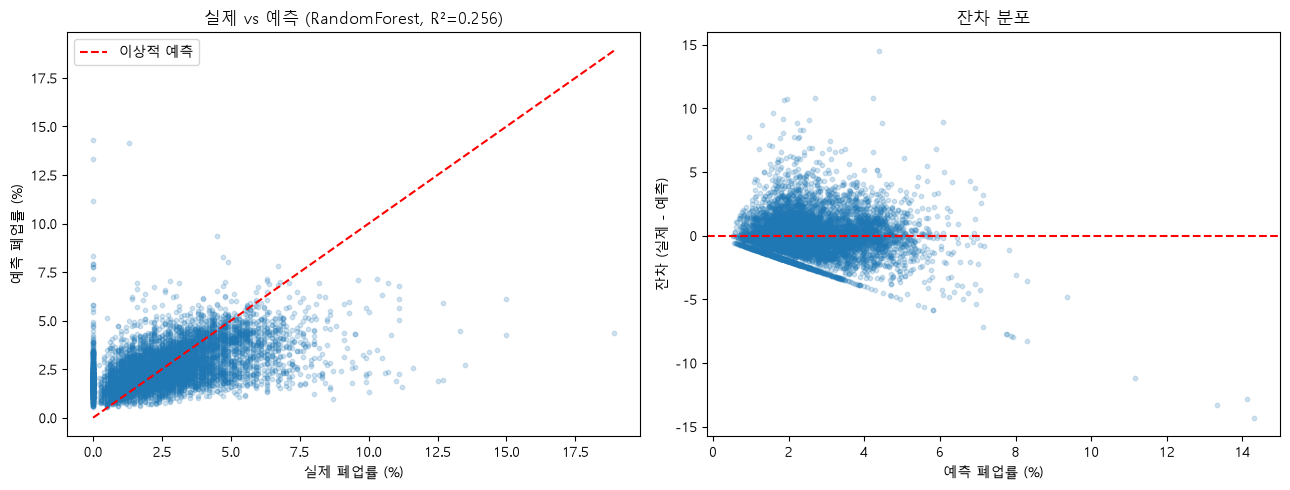

실제 폐업률 범위: 0.0 ~ 18.9%
예측 폐업률 범위: 0.5 ~ 14.3%  (실제보다 좁게 수렴)


In [5]:
best = results_df['R2'].idxmax()
pred = preds[best]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, pred, alpha=0.2, s=10)
lim = [0, y_test.max()]
axes[0].plot(lim, lim, 'r--', label='이상적 예측')
axes[0].set_xlabel('실제 폐업률 (%)')
axes[0].set_ylabel('예측 폐업률 (%)')
axes[0].set_title(f'실제 vs 예측 ({best}, R²={results_df.loc[best, "R2"]:.3f})')
axes[0].legend()

residual = y_test.values - pred
axes[1].scatter(pred, residual, alpha=0.2, s=10)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel('예측 폐업률 (%)')
axes[1].set_ylabel('잔차 (실제 - 예측)')
axes[1].set_title('잔차 분포')

plt.tight_layout()
plt.show()

print(f'실제 폐업률 범위: {y_test.min():.1f} ~ {y_test.max():.1f}%')
print(f'예측 폐업률 범위: {pred.min():.1f} ~ {pred.max():.1f}%  (실제보다 좁게 수렴)')

## 4. 이진 분류로 전환하는 근거

### 왜 분류가 더 나은가?
1. **비즈니스 활용성**: "폐업률 3.2%"라는 숫자보다 **"위험 / 정상"** 판정이 의사결정에 직접적
2. **분포 특성**: 폐업률은 우측으로 치우쳐 있어 회귀가 극단값을 못 맞춤 → 구간(위험 여부) 예측이 안정적
3. **성능**: 중앙값 기준 이진 분류로 전환 시 판별 성능(F1, ROC-AUC)이 크게 개선 (다음 노트북에서 확인)

### 전환 방법
- 폐업률 **중앙값 이상** → `closure_risk = 1` (위험)
- 중앙값 미만 → `closure_risk = 0` (정상)

회귀에서 가장 좋았던 모델의 예측을 중앙값 기준으로 이진화했을 때의 판별력을 참고로 확인해 봅니다.

In [6]:
from sklearn.metrics import f1_score, roc_auc_score

threshold = y.median()
y_test_bin = (y_test.values >= threshold).astype(int)
pred_bin = (pred >= threshold).astype(int)

print(f'이진화 임계값(중앙값): {threshold:.2f}%')
print(f'회귀 예측을 이진화했을 때 → F1: {f1_score(y_test_bin, pred_bin):.4f}, '
      f'ROC-AUC: {roc_auc_score(y_test_bin, pred):.4f}')
print('\n→ 애초에 분류 문제로 학습하면 이보다 더 높은 판별력을 얻을 수 있음 (04, 05에서 확인)')

이진화 임계값(중앙값): 2.30%
회귀 예측을 이진화했을 때 → F1: 0.7122, ROC-AUC: 0.7767

→ 애초에 분류 문제로 학습하면 이보다 더 높은 판별력을 얻을 수 있음 (04, 05에서 확인)


## 정리

| 항목 | 회귀 접근 | 분류 접근 (전환) |
|------|-----------|------------------|
| 타겟 | 폐업률 (연속값) | 위험/정상 (0/1) |
| 성능 | R² ≈ 0.25 (낮음) | F1/AUC 기준 개선 |
| 문제점 | 예측이 평균으로 수렴 | - |
| 활용성 | 숫자 해석 필요 | 즉시 의사결정 가능 |

→ 다음: `04_model_comparison.ipynb` — 이진 분류 5개 모델 비교